# Job Market Intelligence: EDA, Hypothesis Testing, and Drift Detection

This notebook performs exploratory data analysis for job postings and salary patterns, evaluates the claim that remote roles pay more, and detects distribution drift between training and production datasets using Evidently.

In [1]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    from evidently.core.report import Report
    from evidently.presets.drift import DataDriftPreset
except ImportError:
    raise ImportError(
        "Evidently is required for this notebook. Install it with `pip install evidently`." 
    )

plt.style.use("seaborn-v0_8")

DATA_DIR = Path("../data").resolve()
TRAIN_PATH = DATA_DIR / "job_postings_training.csv"
PROD_PATH = DATA_DIR / "job_postings_production.csv"


def load_job_data():
    """Load training and production job data from local CSV files."""
    if TRAIN_PATH.exists() and PROD_PATH.exists():
        train_df = pd.read_csv(TRAIN_PATH, parse_dates=["posted_date"], skipinitialspace=True)
        prod_df = pd.read_csv(PROD_PATH, parse_dates=["posted_date"], skipinitialspace=True)

        for df in (train_df, prod_df):
            for col in ["salary_min", "salary_max"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            if "salary_avg" not in df.columns and {"salary_min", "salary_max"}.issubset(df.columns):
                df["salary_avg"] = df[["salary_min", "salary_max"]].mean(axis=1)

        return train_df, prod_df

    raise FileNotFoundError(
        f"Training or production data not found. Expected files at {TRAIN_PATH} and {PROD_PATH}."
    )

train_df, prod_df = load_job_data()


## Inspect Dataset Structure

Review the loaded datasets to confirm the available fields, data types, and completeness. This step establishes the baseline for the exploratory analysis and highlights missing or malformed values.

In [2]:
display(train_df.head())
print("\nTraining data types:")
print(train_df.dtypes)

print("\nMissing values in training data:")
print(train_df.isna().sum())

print("\nTraining dataset descriptive statistics:")
print(train_df.describe(include='all'))

print("\nDate range for posted_date:")
if "posted_date" in train_df.columns:
    print(train_df["posted_date"].min(), "to", train_df["posted_date"].max())


,id,title,company,location,description,salary_min,salary_max,required_skills,posted_date,source,remote_status,role_type,salary_avg
0,train_001,Data Scientist,DataCorp,"New York, NY",Modeling and analytics work.,110000,140000,Python;SQL;Machine Learning,2025-12-01,kaggle,remote,Data Science,125000.0
1,train_002,Backend Engineer,Buildify,"San Francisco, CA",API and infrastructure development.,130000,160000,Python;Docker;Kubernetes,2025-12-02,linkedin,onsite,Engineering,145000.0
2,train_003,Machine Learning Engineer,NeuroAI,"Austin, TX",Training and deploying models.,125000,155000,Python;PyTorch;SQL,2025-12-03,kaggle,remote,Engineering,140000.0
3,train_004,DevOps Engineer,CloudWay,"Seattle, WA",Pipeline automation and monitoring.,120000,145000,Terraform;Kubernetes;Docker,2025-12-04,linkedin,onsite,DevOps,132500.0
4,train_005,Data Analyst,Insightful,"Boston, MA",Business reporting and dashboards.,90000,115000,SQL;Tableau;Excel,2025-12-05,kaggle,hybrid,Data,102500.0



Training data types:
id                            str
title                         str
company                       str
location                      str
description                   str
salary_min                  int64
salary_max                  int64
required_skills               str
posted_date        datetime64[us]
source                        str
remote_status                 str
role_type                     str
salary_avg                float64
dtype: object

Missing values in training data:
id                 0
title              0
company            0
location           0
description        0
salary_min         0
salary_max         0
required_skills    0
posted_date        0
source             0
remote_status      0
role_type          0
salary_avg         0
dtype: int64

Training dataset descriptive statistics:
               id           title   company      location  \
count          10              10        10            10   
unique         10              10     

## Exploratory Data Analysis: Salary and Role Variables

Explore how the dataset represents salary, remote work status, role type, and skill indicators. This section focuses on the variables needed for the remote salary hypothesis and model drift analysis.

In [3]:
# Ensure the remote indicator is available and normalized
train_df["remote_status"] = train_df["remote_status"].astype(str).str.lower().map({
    "remote": "remote",
    "onsite": "onsite",
    "hybrid": "hybrid"
}).fillna("unknown")

summary = (
    train_df
    .groupby("remote_status")
    .agg(
        count=("id", "count"),
        avg_salary=("salary_avg", "mean"),
        median_salary=("salary_avg", "median"),
        salary_std=("salary_avg", "std")
    )
    .reset_index()
)

display(summary)

print("Role type distribution:")
print(train_df["role_type"].value_counts(dropna=False).head(20))


,remote_status,count,avg_salary,median_salary,salary_std
0,hybrid,2,127500.0,127500.0,35355.339059
1,onsite,4,138125.0,138750.0,17123.935490
2,remote,4,133125.0,133750.0,6884.463184


Role type distribution:
role_type
Engineering     4
Data Science    1
DevOps          1
Data            1
Product         1
Research        1
Architecture    1
Name: count, dtype: int64


## Visualize Salary Distributions for Remote vs Onsite

Visual comparisons make it easier to see whether the salary distributions differ by remote status.

/var/folders/_0/k8jrf2zn4jg29xjy7l9gjy300000gn/T/ipykernel_81233/176808447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


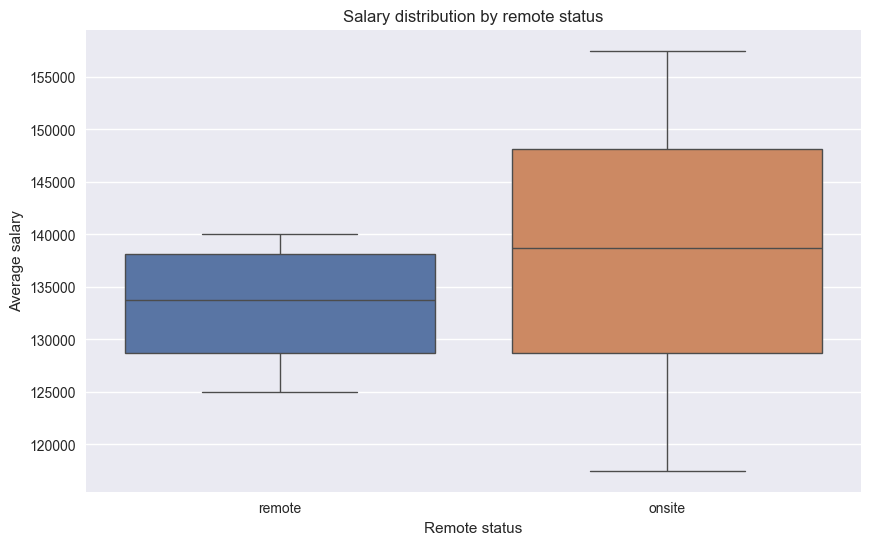

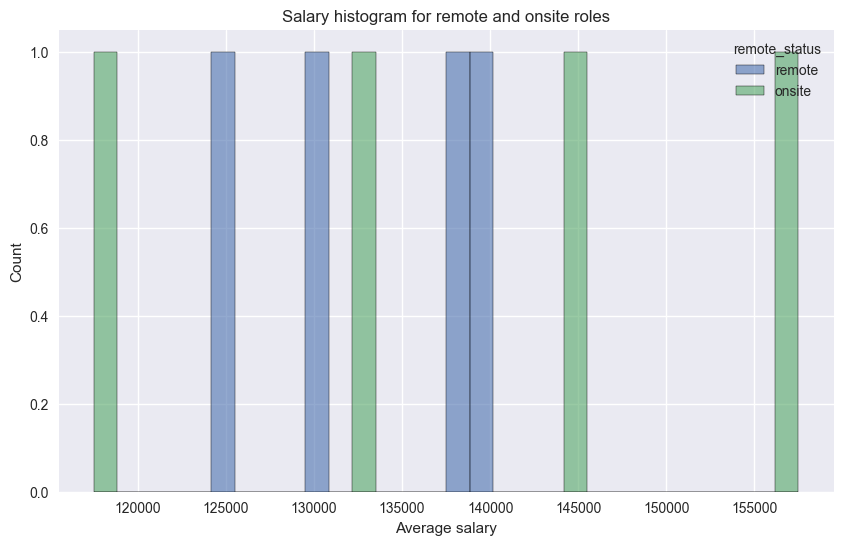

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=train_df[train_df["remote_status"].isin(["remote", "onsite"])],
    x="remote_status",
    y="salary_avg",
    palette=["#4c72b0", "#dd8452"]
)
plt.title("Salary distribution by remote status")
plt.xlabel("Remote status")
plt.ylabel("Average salary")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=train_df[train_df["remote_status"].isin(["remote", "onsite"])],
    x="salary_avg",
    hue="remote_status",
    multiple="layer",
    alpha=0.6,
    bins=30
)
plt.title("Salary histogram for remote and onsite roles")
plt.xlabel("Average salary")
plt.ylabel("Count")
plt.show()


## Statistical Hypothesis Testing: Remote Salary Comparison

This test uses remote and onsite salary samples to evaluate whether remote roles have a higher average salary. The null hypothesis assumes no difference, while the alternative hypothesis assumes remote salaries are greater.

In [5]:
remote_salaries = train_df.loc[train_df["remote_status"] == "remote", "salary_avg"].dropna()
onsite_salaries = train_df.loc[train_df["remote_status"] == "onsite", "salary_avg"].dropna()

print("Remote count:", len(remote_salaries))
print("Onsite count:", len(onsite_salaries))

# Use an independent t-test with unequal variances.
stat, p_value = stats.ttest_ind(remote_salaries, onsite_salaries, equal_var=False, nan_policy="omit")

print(f"t-statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

remote_mean = remote_salaries.mean()
onsite_mean = onsite_salaries.mean()

print(f"Mean remote salary: {remote_mean:.2f}")
print(f"Mean onsite salary: {onsite_mean:.2f}")

alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant at alpha=0.05.")
else:
    print("The difference is not statistically significant at alpha=0.05.")


Remote count: 4
Onsite count: 4
t-statistic: -0.5418
p-value: 0.617086
Mean remote salary: 133125.00
Mean onsite salary: 138125.00
The difference is not statistically significant at alpha=0.05.


## Prepare Training and Production Data for Drift Detection

Select features and ensure the training and production datasets are aligned. Evidently requires the same feature names in both datasets for the drift report.

In [6]:
features = [
    "salary_avg",
    "remote_status",
    "role_type",
    "location",
    "company",
]

train_drift_df = train_df.copy()
prod_drift_df = prod_df.copy()

for df in [train_drift_df, prod_drift_df]:
    if "salary_avg" not in df.columns:
        df["salary_avg"] = df[["salary_min", "salary_max"]].mean(axis=1)
    df["remote_status"] = df["remote_status"].astype(str).str.lower().map({
        "remote": "remote",
        "onsite": "onsite",
        "hybrid": "hybrid"
    }).fillna("unknown")

selected_features = [col for col in features if col in train_drift_df.columns and col in prod_drift_df.columns]
print("Selected features for drift detection:", selected_features)
train_drift_df = train_drift_df[selected_features]
prod_drift_df = prod_drift_df[selected_features]


Selected features for drift detection: ['salary_avg', 'remote_status', 'role_type', 'location', 'company']


## Detect Data Drift with Evidently

Create an Evidently report to compare the training and production data distributions. This report highlighted changes in feature distributions that matter for model stability.

In [7]:
report = Report(metrics=[DataDriftPreset()])
snapshot = report.run(current_data=prod_drift_df, reference_data=train_drift_df)

snapshot.save_html("/tmp/evidently_drift_report.html")
print("Saved drift report to /tmp/evidently_drift_report.html")


Saved drift report to /tmp/evidently_drift_report.html


## Summarize Drift Findings

The report above should show whether the production environment has shifted from the training distribution on key features. Document any features with significant drift and prioritize them for retraining or monitoring.